In [1]:
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import math
import scipy
from scipy.spatial import cKDTree
from scipy import integrate
from scipy import interpolate
from scipy.spatial import Delaunay
from scipy.spatial import Voronoi
from itertools import product
import torch
torch.manual_seed(100000)
import torch.nn as nn
import torch.optim as optim
import pysindy as ps
import pandas as pd
import seaborn as sns



/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/feature_library/base.py:40: DeprecationWarning: Library ensembling is no longer performed by feature libraries.  Use EnsemblingOptimizer to fit an ensemble model.
  warnings.warn(


In [2]:
#settings
start = np.array((0., 1., 1.05))
dt = 0.01
subset_size = 20#50 #cell number
slope =0.1#0.5#1#2 #parameter in weight computation
traj_length = int(1e6)#length of trajectory
noise_level = 0.25#.9#7#5#.9#0.8
sample_size = int(500)#int(subset_size*50)
epsilon = 1e-4
sampling_time = 1
simulation_t =int(2e4)# int(1e5)#int(2e4)
steps = 5
stopping = 0.05

In [3]:

# Define the Lorenz-63 System
def Lorenz(x):
    x = x.T
    dx = 10 * (x[1] - x[0])
    dy = x[0] * (28 - x[2]) - x[1]
    dz = x[0] * x[1] - (8/3) * x[2]
    f = np.array((dx, dy, dz)).T
    return f


def Lorenz_vec(x):
    dx = 10 * (x[:,1] - x[:,0])
    dy = x[:,0] * (28 - x[:,2]) - x[:,1]
    dz = x[:,0] * x[:,1] - (8/3) * x[:,2]
    return torch.cat((dx.reshape(len(x),1),dy.reshape(len(x),1),dz.reshape(len(x),1)),dim = 1)

 #trajectory simulation (Euler's method)
def traj(length, starts = start, model = Lorenz):
    x = starts
    traj = np.zeros((length,len(starts)))
    traj[0] = np.array(x)
    for timestep in range(length-1):

        x = x + dt * model(x)

        traj[timestep+1] = np.array(x)

    return traj

def invariant_measure(matrix):
    N = len(matrix)
    rhs = (-1) * (epsilon/N) * torch.ones(N)
    rho = torch.linalg.solve(((1 - epsilon) * matrix - torch.eye(N)),rhs)
    return rho

trajectory_clean = traj(traj_length)

trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,3)))#loooooooong trajectory
trajectory = trajectory[int(1e3):]
rand_idxs = np.random.choice(len(trajectory), size=sample_size, replace=False)
observed = trajectory[rand_idxs]
randpts = torch.tensor(trajectory[rand_idxs],dtype = torch.float)
Trandpts = torch.tensor(trajectory[rand_idxs+steps],dtype = torch.float)

#normalization
M_scale = torch.max(torch.abs(randpts))
randpts /= M_scale
Trandpts /= M_scale

#Voronoi cell center
Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_

tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)

#count points in each cell
def count_occurrences(arr):
    unique_elements, counts = np.unique(arr, return_counts=True)
    result_array = np.zeros(np.max(unique_elements) + 1, dtype=int)
    result_array[unique_elements] += counts
    return result_array

randpts_idxs = tree.query(randpts)[1]#corresponding cells for each randomly sampled point
sampled_cell_sizes = torch.tensor(count_occurrences(randpts_idxs),dtype = torch.float)#number of points in each cell

relu = nn.ReLU()
def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)


def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    mat = (mat.T)/mat.sum(dim = 1)
    return mat
U_true = Ulam(randpts,Trandpts)
im_true = invariant_measure(U_true)
im_true_np = im_true.detach().cpu().numpy()
class W2Loss(torch.autograd.Function):
    @staticmethod
    def forward(ctx, im_net):
        im_net_np = im_net.detach().numpy()
        im_net_np /= np.sum(im_net_np)
        im_true_np_norm = im_true_np / np.sum(im_true_np)  # assumes im_true_np is a global or passed variable

    # Define cost matrix
        costM = ot.dist(np.arange(subset_size).reshape(-1, 1), 
                        np.arange(subset_size).reshape(-1, 1))

    # Compute EMD
        _, log = ot.emd(im_true_np_norm, im_net_np, costM, log=True)
        cost,grad = log['cost'],log["v"]
        loss = np.sum(cost)
        grad_tensor = torch.tensor(grad, dtype=im_net.dtype)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,)


/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


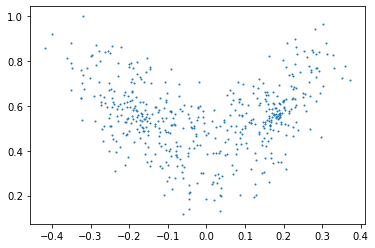

In [4]:
plt.scatter(randpts[:,0],randpts[:,2],s = 1)

Iteration 0, Loss(Ours): 0.00011179634020663798


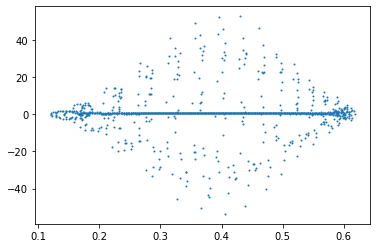

Iteration 500, Loss(Ours): 6.912538083270192e-05
Iteration 1000, Loss(Ours): 7.945260585984215e-05
Iteration 1500, Loss(Ours): 7.277599252120126e-06
Iteration 2000, Loss(Ours): 3.3057312975870445e-05
Iteration 2500, Loss(Ours): 7.411347178276628e-05
Iteration 3000, Loss(Ours): 7.479121268261224e-05
Iteration 3500, Loss(Ours): 5.3958301577949896e-05
Iteration 4000, Loss(Ours): 9.482958557782695e-05
Iteration 4500, Loss(Ours): 4.350494418758899e-05
Iteration 5000, Loss(Ours): 1.496348613727605e-05


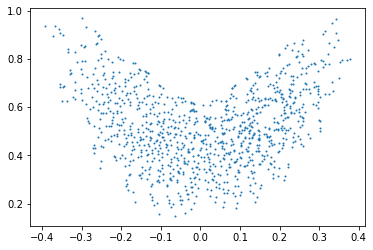

Iteration 5500, Loss(Ours): 1.612337837286759e-05
Iteration 6000, Loss(Ours): 0.00011726900265784934
Iteration 6500, Loss(Ours): 1.2409449482220225e-05
Iteration 7000, Loss(Ours): 2.5558592824381776e-05
Iteration 7500, Loss(Ours): 5.287423118716106e-05
Iteration 8000, Loss(Ours): 0.00011527235619723797
Iteration 8500, Loss(Ours): 0.00010922490037046373
Iteration 9000, Loss(Ours): 5.694313131243689e-06
Iteration 9500, Loss(Ours): 5.7221066526835784e-05
Iteration 10000, Loss(Ours): 5.4692918638465926e-05


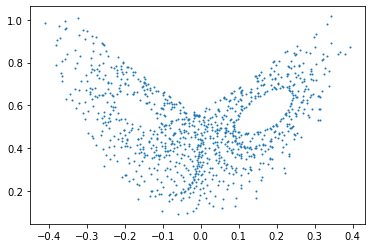

Iteration 10500, Loss(Ours): 4.648088361136615e-05
Iteration 11000, Loss(Ours): 0.00010244461009278893
Iteration 11500, Loss(Ours): 7.691021164646372e-05
Iteration 12000, Loss(Ours): 7.886430103098974e-05
Iteration 12500, Loss(Ours): 4.434551101439865e-06
Early stopping at iteration 12500, Loss: 4.434551101439865e-06


In [5]:
torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(3, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 3))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)
N_iters = 50000

net1.train()
loss1 = []
invert_variables = [0]

net1_randpts = randpts.clone()  # safe copy, avoid modifying original tensor
for _ in range(steps):
    V_field = Lorenz_vec(net1_randpts*M_scale)/M_scale
    V_field[:,invert_variables] = net1(net1_randpts)[:,invert_variables]
    net1_randpts = net1_randpts+dt* V_field
U_net = Ulam(randpts,net1_randpts)
im_net = invariant_measure(U_net)
initial_L1 = torch.linalg.norm(im_net - im_true, dtype=torch.float32)
#initial_L1 = W2Loss.apply(im_net)
for i in range(N_iters):
    optimizer1.zero_grad()
    
    net1_randpts = randpts
    for _ in range(steps):
        V_field = Lorenz_vec(net1_randpts*M_scale)/M_scale
        V_field[:,invert_variables] = net1(net1_randpts)[:,invert_variables]
        net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts,net1_randpts)
    im_net = invariant_measure(U_net)
    #L1 = torch.linalg.matrix_norm(U_net - U_true,ord = 'fro')
    L1 = torch.linalg.norm(im_net - im_true, dtype=torch.float32)
    #L1 = W2Loss.apply(im_net)
    L1.backward()
    optimizer1.step()
    loss1.append(L1.item())


    # Logging
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L1.item()}')
            if L1.item() < stopping * initial_L1:
                print(f"Early stopping at iteration {i}, Loss: {L1.item()}")
                break
    # Visualization every 5000 iterations
    if i % 5000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
        vals1= [x1.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            for j in range(steps):
                V_field = Lorenz_vec(x1*M_scale)/M_scale
                V_field[:,invert_variables] = net1(x1)[:,invert_variables]
                x1 = x1+dt* V_field
                
            vals1.append(x1.detach().numpy().flatten())

        
        vals1= np.array(vals1)
        plt.scatter(vals1[:, 0], vals1[:, 2], s=1)
        plt.show()
        # plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
        # plt.show()

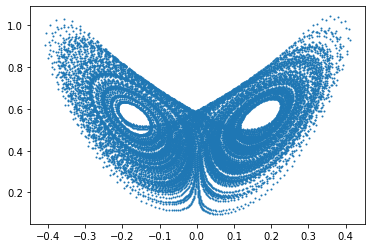

In [6]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
vals1 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):
    #for i in range(steps):
    V_field = Lorenz_vec(x1*M_scale)/M_scale
    V_field[:,invert_variables] = net1(x1)[:,invert_variables]
    x1 = x1+dt* V_field
    vals1.append(x1.detach().numpy().flatten())
vals1 = np.array(vals1)
plt.scatter(vals1[:, 0], vals1[:, 2], s=1)

plt.show()

In [7]:

torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(3, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 3))


optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
net2.train()
loss2 = []
net2_randpts = randpts.clone()  # safe copy, avoid modifying original tensor
for _ in range(steps):
    V_field2 = Lorenz_vec(net2_randpts*M_scale)/M_scale
    V_field2[:,invert_variables] = net2(net2_randpts)[:,invert_variables]
    net2_randpts = net2_randpts+dt* V_field2
initial_L2 = torch.mean((net2_randpts - Trandpts) ** 2)



Iteration 0, Loss(Pointwise): 0.0008610173827037215


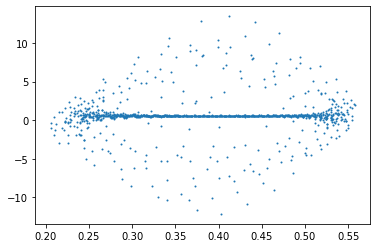

Iteration 500, Loss(Pointwise): 4.940214421367273e-05
Iteration 1000, Loss(Pointwise): 4.9206057155970484e-05
Iteration 1500, Loss(Pointwise): 4.909960989607498e-05
Iteration 2000, Loss(Pointwise): 5.0010821723844856e-05
Iteration 2500, Loss(Pointwise): 4.900699423160404e-05
Iteration 3000, Loss(Pointwise): 4.894052108284086e-05
Iteration 3500, Loss(Pointwise): 4.886040915152989e-05
Iteration 4000, Loss(Pointwise): 4.87904399051331e-05


In [ ]:
for i in range(int(50000)):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()
    # optimizer2.zero_grad()
    
    # Update for net1 (Ulam)
    # net1_randpts = net1(randpts) #parametrize the map

    
    net2_randpts = randpts
    for _ in range(steps):
        V_field2 = Lorenz_vec(net2_randpts*M_scale)/M_scale
        V_field2[:,invert_variables] = net2(net2_randpts)[:,invert_variables]
        net2_randpts = net2_randpts+dt* V_field2


    L2 = torch.mean((net2_randpts - Trandpts) ** 2)
    L2.backward()
    optimizer2.step()
    loss2.append(L2.item())
    

    # Logging
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Pointwise): {L2.item()}')
            if L2.item() < stopping * initial_L2:
                print(f"Early stopping at iteration {i}, Loss: {L2.item()}")
                break
        
        
    # Visualization
    if i % 5000 == 0:
        x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
        vals2 = [x2.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            for j in range(steps):

                V_field2 = Lorenz_vec(x2*M_scale)/M_scale
                V_field2[:,invert_variables] = net2(x2)[:,invert_variables]
                x2 = x2 + V_field2*dt
            vals2.append(x2.detach().numpy().flatten())
        vals2 = np.array(vals2)
        plt.scatter(vals2[:, 0], vals2[:, 2], s=1)
        plt.show()

In [ ]:
x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
vals2 = [x2.detach().numpy().flatten()]
for _ in range(simulation_t-1):

    #for j in range(steps):

    V_field2 = Lorenz_vec(x2*M_scale)/M_scale
    V_field2[:,invert_variables] = net2(x2)[:,invert_variables]
    x2 = x2 + V_field2*dt
    vals2.append(x2.detach().numpy().flatten())
vals2 = np.array(vals2)
plt.scatter(vals2[:, 0], vals2[:, 2], s=1)
plt.show()

In [ ]:
#plt.scatter(vals2[:, 0][-int(1e3):], vals2[:, 2][-int(1e3):], s=1)

In [ ]:
GT = traj(int(simulation_t), M_scale* np.array(randpts[0]))#[::steps]

In [ ]:
subGT = GT
subvals1 = np.array(M_scale * vals1)
subvals2 = np.array(M_scale * vals2)

Subvals1 = subGT.copy()
Subvals2 = subGT.copy()

Subvals1[:, invert_variables] = subvals1[:, invert_variables]
Subvals2[:, invert_variables] = subvals2[:, invert_variables]

a = np.ones(simulation_t) / simulation_t
b = np.ones(simulation_t) / simulation_t

M1 = ot.dist(subGT, Subvals1)
M2 = ot.dist(subGT, Subvals2)

_, G01 = ot.emd(a, b, M1, log=True)
_, G02 = ot.emd(a, b, M2, log=True)

cost1W = np.sqrt(G01['cost'])
cost2W = np.sqrt(G02['cost'])

In [ ]:
    # subGT, subvals1, subvals2 = GT, np.array(M_scale * vals1), np.array(M_scale * vals2)
    # Subvals1 = subGT.copy()
    # Subvals2 = subGT.copy()
    # Subvals1[:, invert_variables] = subvals1[:, invert_variables]
    # Subvals2[:, invert_variables] = subvals2[:, invert_variables]
    # a, b = np.ones((simulation_t,)) / simulation_t, np.ones((simulation_t,)) / simulation_t
    # M1, M2 = ot.dist(subGT, Subvals1),ot.dist(subGT, Subvals2)
    # _,G01 = ot.emd(a, b, M1,log = 'true')
    # _,G02 = ot.emd(a, b, M2,log = 'true')
    # cost1W,cost2W = (G01['cost'])**(1/2),(G02['cost'])**(1/2)



In [ ]:
cost1W,cost2W

In [16]:
    # GTpts = torch.tensor((GT/M_scale)[:-steps],dtype = torch.float)
    # GTTpts = GT[steps:]
    # net1pts,net2pts = GTpts, GTpts
    # for i in range(steps):
    #     Vf1,Vf2 = net1(net1pts),net2(net2pts)
    #     net1pts,net2pts = net1pts+dt*Vf1,net2pts+dt*Vf2
    # pre_net1pts = GTTpts/M_scale
    # pre_net1pts[:,invert_variables] = net1pts[:,invert_variables].to(pre_net1pts.dtype)
    # cost1L = torch.mean((M_scale * pre_net1pts - GTTpts) ** 2).sqrt()
    # #cost2L = torch.mean((M_scale * pre_net1pts - GTTpts) ** 2).sqrt()

In [ ]:
GT = torch.tensor(GT, dtype=torch.float32)
M_scale = torch.tensor(M_scale, dtype=torch.float32)

In [ ]:
GTpts = (GT / M_scale)[:-steps]
GTTpts = GT[steps:]

net1pts, net2pts = GTpts.clone(), GTpts.clone()

for i in range(steps):
    Vf1, Vf2 = net1(net1pts), net2(net2pts)
    net1pts = net1pts + dt * Vf1
    net2pts = net2pts + dt * Vf2

Net1pts = (GTTpts / M_scale).clone()
Net2pts = (GTTpts / M_scale).clone()
Net1pts[:, invert_variables] = net1pts[:, invert_variables]
Net2pts[:, invert_variables] = net2pts[:, invert_variables]

cost1L = torch.sqrt(torch.mean((M_scale * Net1pts - GTTpts) ** 2))
cost2L = torch.sqrt(torch.mean((M_scale * Net2pts - GTTpts) ** 2))

In [ ]:
cost1L.detach().numpy()

In [ ]:
    print("W2(ours) ",cost1W, ", W2(pointwise) ",cost2W)
    print("L2(ours) ",cost1L, ", L2(pointwise) ",cost2L)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi = 300)

axes[1].plot(M_scale * vals1[:, 0], M_scale * vals1[:, 2], linewidth=0.2)
axes[1].set_title('Measure Matching')

# Plot vals_ode (neural ODE results)
axes[2].plot(M_scale * vals2[:, 0], M_scale * vals2[:, 2], linewidth=0.2)
axes[2].set_title('Pointwise')

# Plot ground truth trajectory
axes[0].plot(GT[:, 0], GT[:, 2], label="Ground Truth", linewidth=0.2, zorder=1, c = "black")
axes[0].scatter(M_scale * randpts[:, 0], M_scale * randpts[:, 2], s=1, c="tomato", alpha = 1,
                label="Training samples", zorder=2)
axes[0].set_title('Ground Truth and Training samples')
axes[0].legend(loc='upper left')

# Set axis labels and layout
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()


for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_aspect('equal')

#fig.text(0.04, 0.5, 'Lorenz-63', va='center', rotation='vertical', fontsize=14)
#plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()